# Comparing AutoAugment Strategies

In [1]:
from typing import Literal

import torch
from torch.utils.data import DataLoader

from src.configs import get_avail_splits, get_class_list, set_seed
from src.run_types import (
    AVAIL_SETS,
    AVAIL_SPLITS,
    SEED,
    AutoAugmentConfig,
    CentreCropConfig,
    OG_Sampler,
)
from src.utils import plt_display_grid
from src.video_dataset import VideoDataset, get_transform, get_wlasl_info
from src.visualise2 import set_thesis_style

AutoAugPolicy = Literal["IMAGENET", "CIFAR10", "SVHN"]

In [ ]:
set_thesis_style()
set_seed(SEED)

## Setup

In [ ]:
av_splits = get_avail_splits()
for s in av_splits:
    print(s)

split_name: AVAIL_SPLITS = "asl100"
set_name: AVAIL_SETS = "test"
print(split_name, set_name)

test_info = get_wlasl_info(split_name, set_name)
print(test_info)

class_list = get_class_list()
print(len(class_list))

asl100_bottom
asl100
asl300_cutoff_9
asl2000
asl300
asl100_worst
asl100_cutoff_9
asl2000_cutoff_9
asl1000
asl1000_cutoff_9


## AutoAugment policies

Build a shared crop + frame-sampler transform, varying only the spatial `AutoAugment` policy (or
applying none, as a control), so each policy's effect can be compared directly against the same
clip.

In [ ]:
from src.run_types import SpatialAugs

FRAME_SIZE = 224
TARGET_LENGTH = 16

def build_transform(policy: AutoAugPolicy | None):
    spatial_aug : list[SpatialAugs] = [CentreCropConfig(frame_size=FRAME_SIZE)]
    if policy is not None:
        spatial_aug.append(AutoAugmentConfig(type=policy))

    transform, _, _ = get_transform(
        temporal_aug=[OG_Sampler(target_length=TARGET_LENGTH)],
        spatial_aug=spatial_aug,
        normalise_to_float=False,
        permute_time_channel=False,
    )
    return transform

## Examine frames

Bring a batch's frames into `(T, C, H, W)` order for display.

In [8]:
def prep_frames(batch: dict[str, torch.Tensor]) -> torch.Tensor:
    frames = batch["frames"]
    if frames.dim() == 5:
        frames = frames.squeeze(0)
    if frames.shape[1] != 3:
        frames = frames.permute(1, 0, 2, 3)  # swap T and C
    return frames

## Compare control vs. each policy

`shuffle=False`, so the first item drawn from the loader is always the same clip — only the
transform changes between calls.

In [9]:
def show_policy(policy: AutoAugPolicy | None) -> None:
    transform = build_transform(policy)
    dataset = VideoDataset(set_info=test_info, transforms=transform)
    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
    sample = next(iter(loader))
    frames = prep_frames(sample)

    label = policy if policy is not None else "Control (no AutoAugment)"
    print(f"{label} - class: {class_list[int(sample['label_num'])]}")
    plt_display_grid(frames, TARGET_LENGTH, size=(2, 2), cols=4)

### Control (no AutoAugment)

Control (no AutoAugment) - class: book


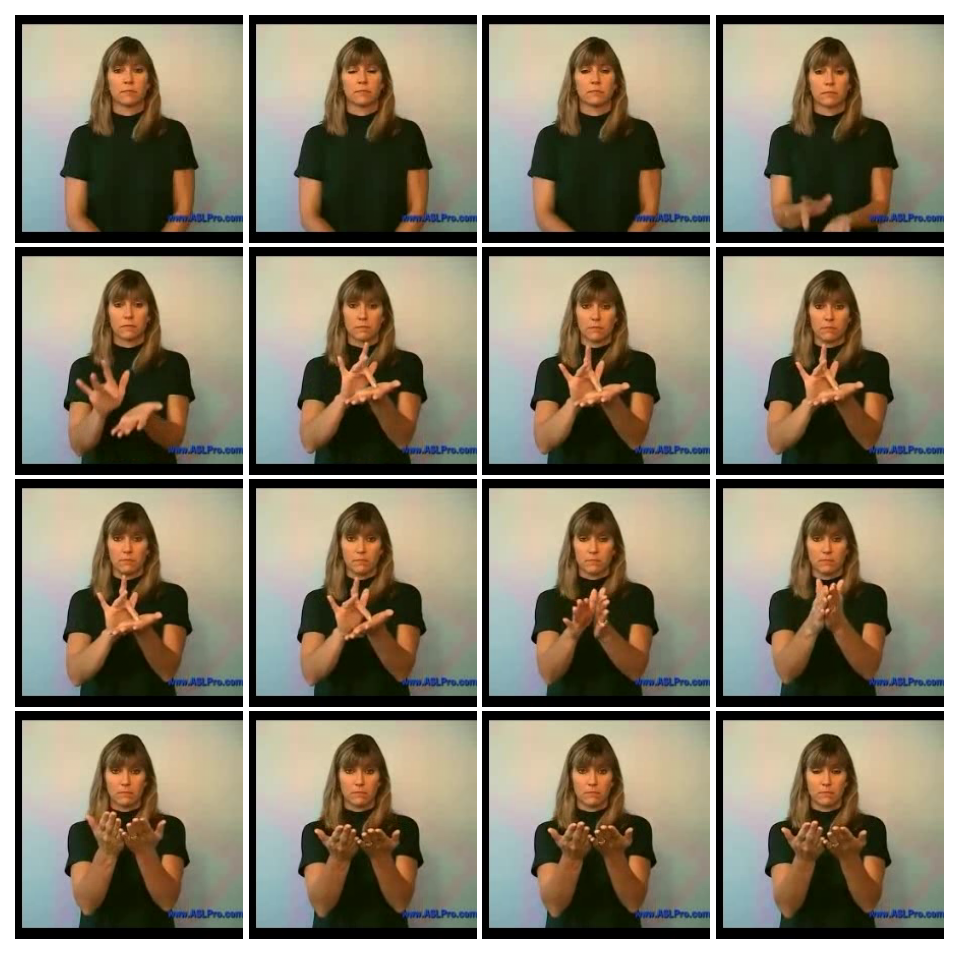

In [10]:
show_policy(None)

### IMAGENET

IMAGENET - class: book


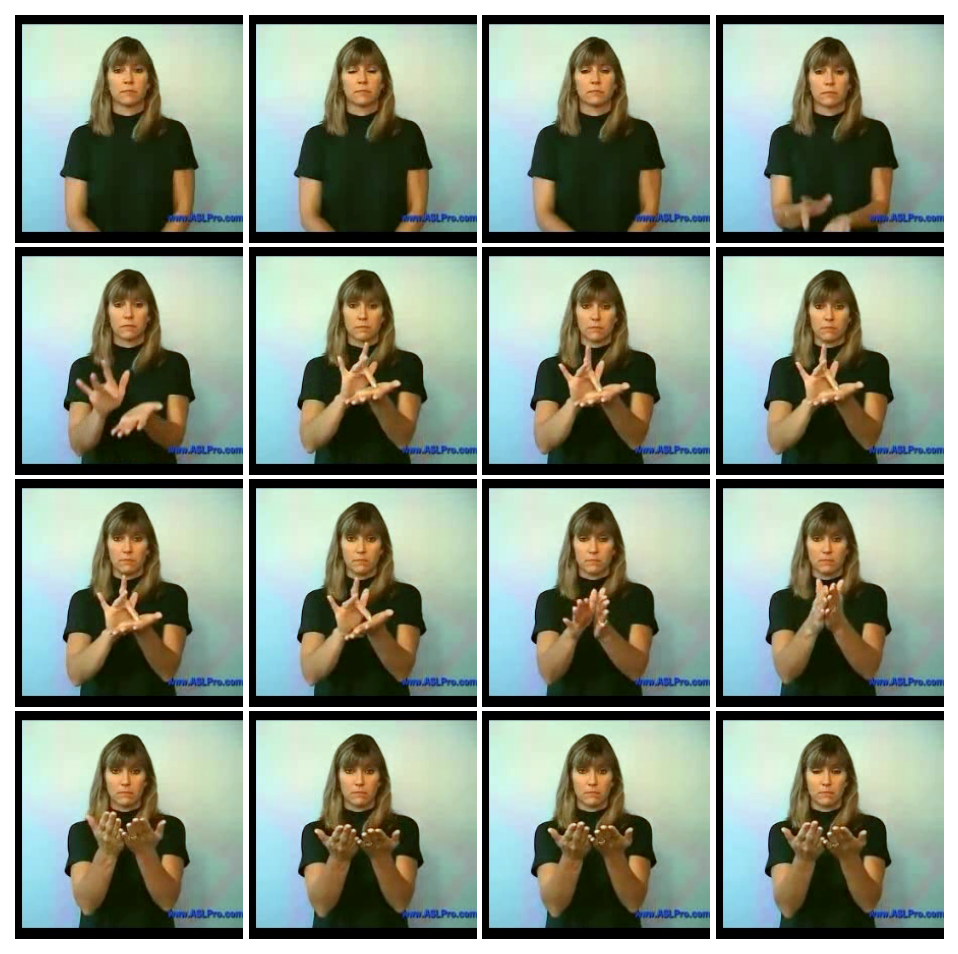

In [11]:
show_policy("IMAGENET")

### CIFAR10

CIFAR10 - class: book


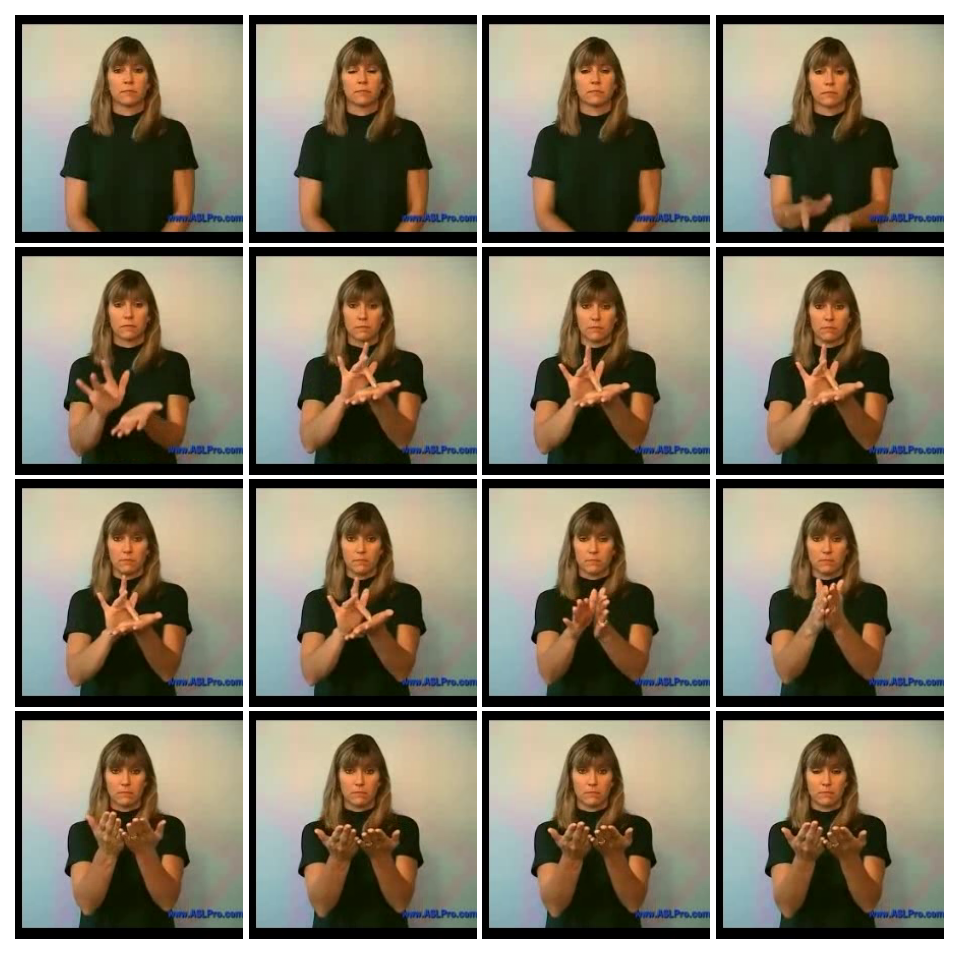

In [12]:
show_policy("CIFAR10")

### SVHN

SVHN - class: book


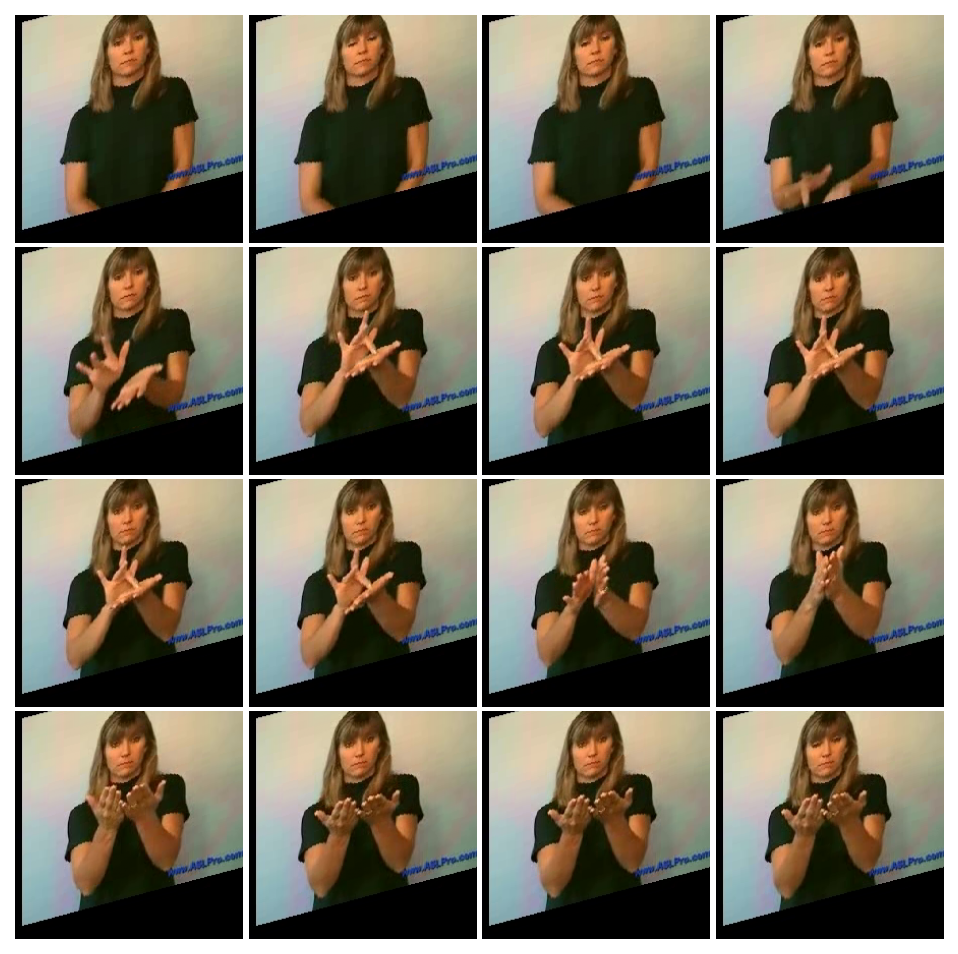

In [13]:
show_policy("SVHN")

# Conclusion

On this clip (asl100 test, class "book"), the control, ImageNet, and CIFAR-10 views all landed on
near-identity ops for every sampled frame — no visible change from the control grid. The SVHN
policy, on the other hand, introduced a visible shear/rotation on several frames (note the black
wedge appearing in the corners), while leaving the frame count and signer otherwise intact. This
is expected, not a bug: each policy samples its op (and magnitude) per frame from a bank that
includes `Identity`, so a given policy won't necessarily produce a visible change on every run —
and the SVHN policy in particular leans more heavily on geometric ops (shear/rotate) than the
ImageNet/CIFAR-10 policies do. Re-running this notebook with a different `SEED` (or on a longer
clip) will sample different ops per policy.